Functions for data reading

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_sensor_definitions(sensor_definitions_file):
    """Load sensor definitions and extract required mappings."""
    sensor_definitions = pd.read_csv(sensor_definitions_file)
    sensor_definitions.columns = sensor_definitions.columns.str.strip()  # Trim spaces
    
    # Create a dictionary mapping physical channels to their scaling factors
    scaling_dict = {}
    for index, row in sensor_definitions.iterrows():
        channel = row["Sensor Physical Channel"]
        equation = row["Scaling Equation"]
        factor = float(equation.split("*")[1])  # Extract scaling factor from "x*100"
        scaling_dict[channel] = factor
    
    return sensor_definitions, scaling_dict

def load_and_process_raw_data(raw_data_file, sensor_definitions, scaling_dict):
    """Load raw sensor data, extract relevant columns, apply scaling, and normalize time."""
    sensor_channels = list(sensor_definitions["Sensor Physical Channel"])
    use_cols = [0] + [i + 1 for i in range(len(sensor_channels))]

    raw_data = pd.read_csv(raw_data_file, comment='#', header=None, usecols=use_cols)
    raw_data.columns = ["NI_9205_ai_time"] + sensor_channels

    # Convert all relevant columns to numeric
    raw_data["NI_9205_ai_time"] = pd.to_numeric(raw_data["NI_9205_ai_time"], errors="coerce")
    for channel in sensor_channels:
        raw_data[channel] = pd.to_numeric(raw_data[channel], errors="coerce")

    # Drop bad rows
    raw_data = raw_data.dropna(subset=["NI_9205_ai_time"])

    # Normalize time to seconds from start
    raw_data["NI_9205_ai_time"] = (
        raw_data["NI_9205_ai_time"] - raw_data["NI_9205_ai_time"].iloc[0]
    ) / 1e9

    print(raw_data["NI_9205_ai_time"].min())
    print(raw_data["NI_9205_ai_time"].max())

    # Apply scaling
    for channel in sensor_channels:
        raw_data[channel] *= scaling_dict[channel]

    return raw_data, sensor_channels

def plot_sensors(raw_data, sensor_channels, sensor_definitions, time_min=None, time_max=None):
    """Plot each sensor individually over the selected time range."""
    if time_min is not None and time_max is not None:
        raw_data = raw_data[(raw_data["NI_9205_ai_time"] >= time_min) & (raw_data["NI_9205_ai_time"] <= time_max)]

    num_sensors = len(sensor_channels)
    fig, axes = plt.subplots(nrows=num_sensors, ncols=1, figsize=(10, 2 * num_sensors))

    for i, channel in enumerate(sensor_channels):
        axes[i].plot(raw_data["NI_9205_ai_time"], raw_data[channel], label=sensor_definitions.loc[i, "Sensor Name"])
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel(f"{sensor_definitions.loc[i, 'Resulting Units']}")
        axes[i].set_title(sensor_definitions.loc[i, "Sensor Name"])
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()
    raw_data_parsed = raw_data
    return raw_data_parsed

Apply Different Orifices

0.0
72.836273408


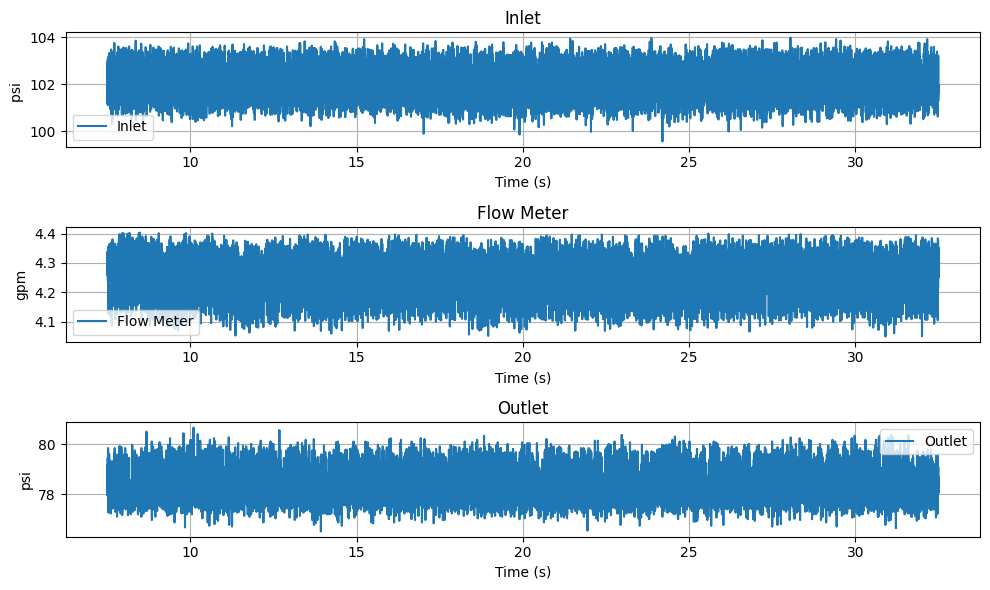

In [92]:
# Define file paths for a new orifice test
sensor_definitions_file = r"C:\Users\alexa\Desktop\Solenoid_CV_Test\OrificeDefs.csv"
raw_data_file = r"C:\Users\alexa\Desktop\Solenoid_CV_Test\GOON_Test_1.csv" # Change this for each new test

# Load sensor definitions and scaling factors
sensor_definitions, scaling_dict = load_sensor_definitions(sensor_definitions_file)

# Load and process raw data
raw_data, sensor_channels = load_and_process_raw_data(raw_data_file, sensor_definitions, scaling_dict)

# Plot data within a specific time range
raw_data_parsed = plot_sensors(raw_data, sensor_channels, sensor_definitions, time_min = 7.5, time_max = 32.5)

Cd and Cv calcs

In [93]:
def plot_pressure_differences(pressure_diffs):
    """Plot pressure differences over time."""
    
    num_plots = len(pressure_diffs.columns) - 1  # Exclude 'Time' column
    fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 3 * num_plots))

    if num_plots == 1:
        axes = [axes]  # Ensure iterable for single plot

    for i, col in enumerate(pressure_diffs.columns[1:]):  # Skip 'Time' column
        axes[i].plot(pressure_diffs.loc[:, "Time"], pressure_diffs.loc[:, col], label=col)
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Pressure Difference (psi)")
        axes[i].set_title(col)
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def plot_C_v(C_vOrifice):
    plt.figure(figsize=(10, 6))
    plt.plot(raw_data_parsed["Time"], C_vOrifice, label="C_v Orifice")
    
    plt.xlabel("Time (s)")
    plt.ylabel("C_v Value")
    plt.title("Flow Coefficient (Cv) Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()


def calculate_Cv(Q_actual, delta_P):
    print("Q_actual.mean(): " + str(Q_actual.mean()))
    print("delta_P.mean(): " + str(delta_P.mean()))
    C_v = Q_actual / np.sqrt((delta_P/1))
    return C_v

Functions

In [94]:
Q_actual = raw_data_parsed.iloc[:,2]

#Pintle_avg = raw_data_parsed.iloc[:,[4,6]].mean(axis=1)

Total_deltaP = raw_data_parsed.iloc[:,3]#main to ambient
delta_P_mean = Total_deltaP.mean()
print("\nDelta P:"+ str(delta_P_mean))
#print(Total_deltaP)
C_vOrifice = calculate_Cv(Q_actual, Total_deltaP)
C_vOrifice_mean = C_vOrifice.mean()
print("\nC_v Orifice:" + C_vOrifice_mean.astype(str))


Delta P:78.18735429870605
Q_actual.mean(): 4.272351462195396
delta_P.mean(): 78.18735429870605

C_v Orifice:0.48317029996509125
